--- DATASET OVERVIEW ---
Dataset Shape: 25180 rows, 35 columns

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      247

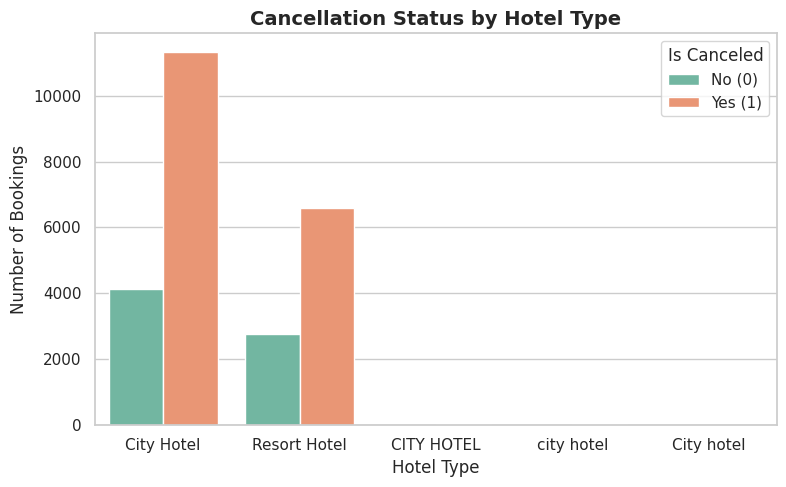

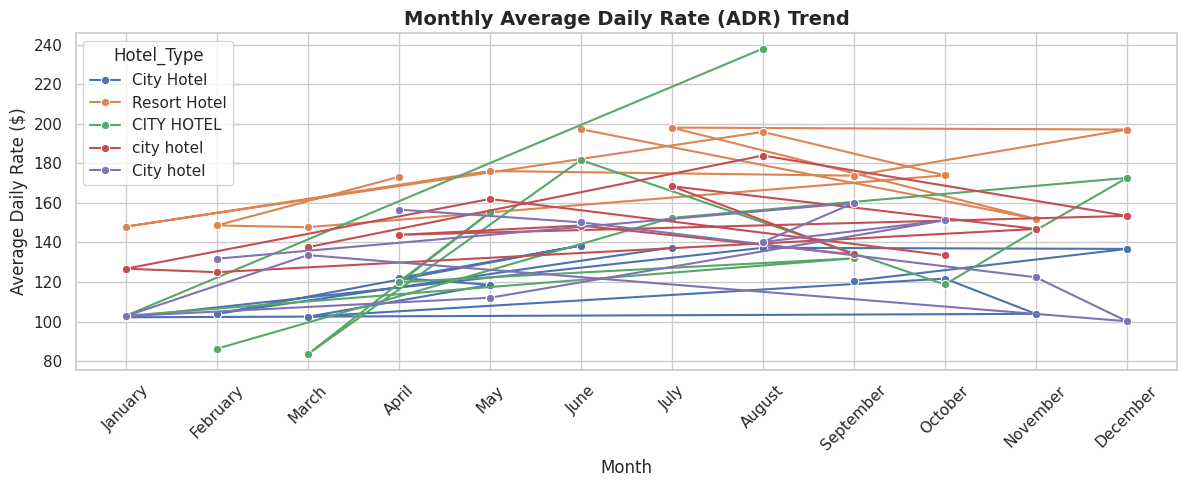

/tmp/ipykernel_1051/3071256981.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


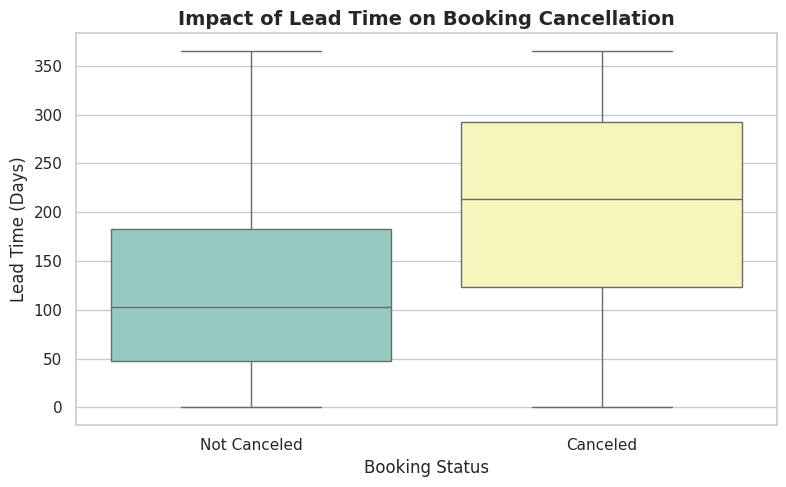

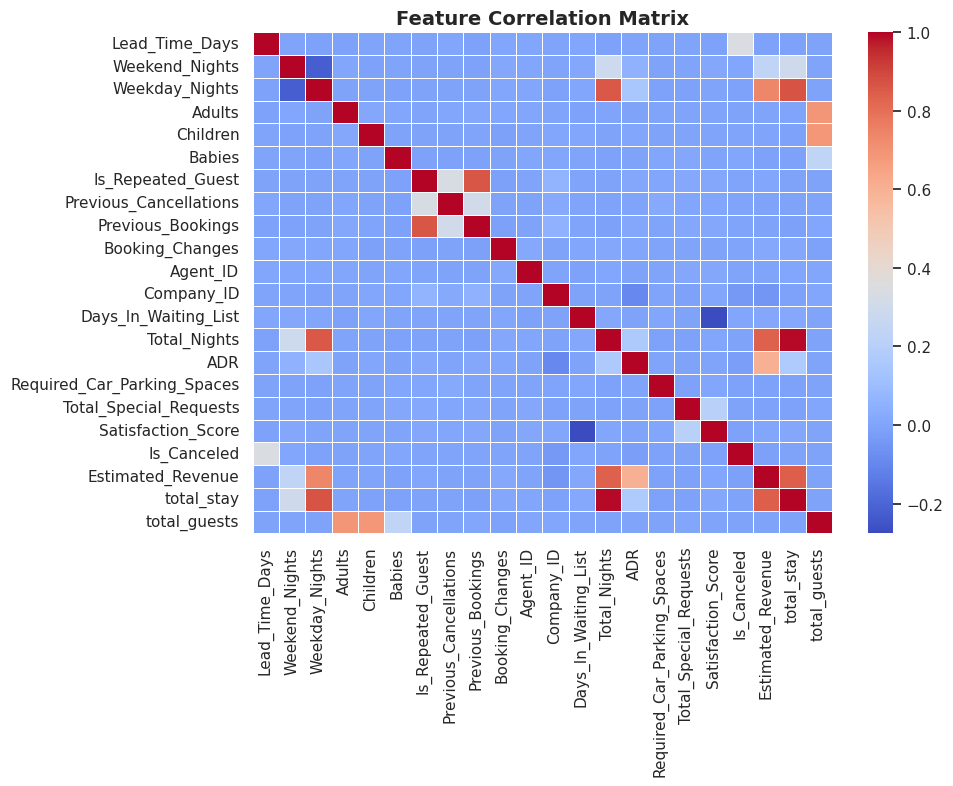

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

df = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")

print("--- DATASET OVERVIEW ---")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Data Types & Missing Values ---")
print(df.info())

print("\n--- Duplicate Records ---")
print(f"Total Duplicates: {df.duplicated().sum()}")

df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

if "Children" in df_clean.columns:
    df_clean["Children"] = df_clean["Children"].fillna(0)
if "Country" in df_clean.columns:
    df_clean["Country"] = df_clean["Country"].fillna("Unknown")
if "Agent_ID" in df_clean.columns:
    df_clean["Agent_ID"] = df_clean["Agent_ID"].fillna(0)
if "Company_ID" in df_clean.columns:
    df_clean["Company_ID"] = df_clean["Company_ID"].fillna(0)

guest_cols = [
    col for col in ["Adults", "Children", "Babies"] if col in df_clean.columns
]
if guest_cols:
    df_clean = df_clean[df_clean[guest_cols].sum(axis=1) > 0]

if "ADR" in df_clean.columns:
    df_clean = df_clean[
        (df_clean["ADR"] >= 0) & (df_clean["ADR"] < 5000)
    ]

df_clean["total_stay"] = (
    df_clean["Weekend_Nights"] + df_clean["Weekday_Nights"]
)
df_clean["total_guests"] = (
    df_clean["Adults"] + df_clean["Children"] + df_clean["Babies"]
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_clean,
    x="Hotel_Type",
    hue="Is_Canceled",
    palette="Set2",
)
plt.title("Cancellation Status by Hotel Type", fontsize=14, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Is Canceled", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

if "Arrival_Date" in df_clean.columns:
    # Extract month from 'Arrival_Date' for plotting
    df_clean['arrival_month'] = pd.to_datetime(df_clean['Arrival_Date']).dt.month_name()
    months_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]
    df_clean['arrival_month'] = pd.Categorical(df_clean['arrival_month'], categories=months_order, ordered=True)

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=df_clean,
        x="arrival_month",
        y="ADR",
        hue="Hotel_Type",
        estimator="mean",
        errorbar=None,
        marker="o",
        sort=False
    )
    plt.xticks(rotation=45)
    plt.title(
        "Monthly Average Daily Rate (ADR) Trend", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Month")
    plt.ylabel("Average Daily Rate ($)")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean, x="Is_Canceled", y="Lead_Time_Days", palette="Set3", showfliers=False
)
plt.title(
    "Impact of Lead Time on Booking Cancellation",
    fontsize=14,
    fontweight="bold",
)
plt.xticks([0, 1], ["Not Canceled", "Canceled"])
plt.xlabel("Booking Status")
plt.ylabel("Lead Time (Days)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()